# Microsoft Stock Price Prediction Using LSTM and GRU

## Project Objective

This project aims to predict the next-day closing price of Microsoft (MSFT) stock using historical stock market data.

Two deep learning models, **Long Short-Term Memory (LSTM)** and **Gated Recurrent Unit (GRU)**, are implemented using the PyTorch framework. Both models are trained and evaluated under the same experimental conditions to ensure a fair comparison.

The performance of the models is evaluated using the **Root Mean Squared Error (RMSE)** metric, and the prediction results are compared through numerical analysis and visualization.

## Dataset

The dataset contains the historical daily stock prices of Microsoft (MSFT). In this project, the **Close** price is used as the target variable for prediction. To focus on recent market behavior, only data from **2010 onwards** is used for model training and evaluation.

##  Import Libraries

In this section, the required Python libraries are imported.

- **Pandas** is used for data manipulation.
- **NumPy** is used for numerical operations.
- **Matplotlib** is used for visualization.
- **Scikit-learn** is used for data preprocessing and evaluation metrics.
- **PyTorch** is used to build and train the LSTM and GRU deep learning models.

In [ ]:
# Data processing
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn

# Preprocessing and evaluation
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
GPU available: False


##  Load Dataset

The Microsoft historical stock price dataset is loaded into a Pandas DataFrame.

Before building any deep learning model, the dataset is inspected to understand:

- Number of observations
- Available features
- Data types
- Missing values

This step helps identify potential data quality issues before preprocessing.

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'Microsoft_stock_data.csv', 'sample_data']


## Exploratory Data Analysis (EDA)

The dataset is explored to better understand its structure.

The following checks are performed:

- Dataset dimensions
- Feature names
- Data types
- Missing values

These checks ensure that the dataset is suitable for further preprocessing and model training.

In [ ]:
file_path = "/content/Microsoft_stock_data.csv"

df = pd.read_csv(file_path)

display(df.head())

print("Data shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

,Date,Close,High,Low,Open,Volume
0,1986-03-26,0.057666,0.058195,0.055550,0.056079,22752000
1,1986-03-27,0.058724,0.058724,0.057666,0.057666,16848000
2,1986-03-31,0.058195,0.058724,0.057137,0.058724,12873600
3,1986-04-01,0.057666,0.058195,0.057666,0.058195,11088000
4,1986-04-02,0.058195,0.059253,0.057666,0.057666,27014400


Data shape: (10094, 6)

Columns:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10094 entries, 0 to 10093
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    10094 non-null  object 
 1   Close   10094 non-null  float64
 2   High    10094 non-null  float64
 3   Low     10094 non-null  float64
 4   Open    10094 non-null  float64
 5   Volume  10094 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 473.3+ KB

Missing values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## Data Preprocessing

The dataset is prepared before model training.

The preprocessing steps include:

- Converting the **Date** column into datetime format
- Sorting the dataset chronologically
- Selecting the **Close** price as the prediction target


These steps ensure that the time series is correctly ordered and suitable for forecasting.

In [ ]:
# Date sütununu datetime formatına çevir


df["Date"] = pd.to_datetime(df["Date"])

# Tarihe göre sırala
df = df.sort_values("Date")

# İndeksi yeniden düzenle
df = df.reset_index(drop=True)

# Kontrol edelim
print(df.dtypes)

display(df.head())

display(df.tail())

Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object


,Date,Close,High,Low,Open,Volume
0,1986-03-26,0.057666,0.058195,0.055550,0.056079,22752000
1,1986-03-27,0.058724,0.058724,0.057666,0.057666,16848000
2,1986-03-31,0.058195,0.058724,0.057137,0.058724,12873600
3,1986-04-01,0.057666,0.058195,0.057666,0.058195,11088000
4,1986-04-02,0.058195,0.059253,0.057666,0.057666,27014400


,Date,Close,High,Low,Open,Volume
10089,2026-04-14,393.109985,394.690002,386.519989,387.920013,37504500
10090,2026-04-15,411.220001,414.369995,396.730011,398.000000,45063400
10091,2026-04-16,420.260010,420.820007,412.140015,419.859985,41642400
10092,2026-04-17,422.790009,431.579987,420.690002,424.820007,48568200
10093,2026-04-20,418.070007,423.329987,416.299988,421.144989,27240190


###  Closing Price Trend

Before training the deep learning models, the historical closing prices of Microsoft stock are visualized.

This visualization provides an overview of the long-term price trend and helps identify periods of growth, decline, and overall market behavior. Understanding the trend is useful before applying preprocessing techniques and building forecasting models.

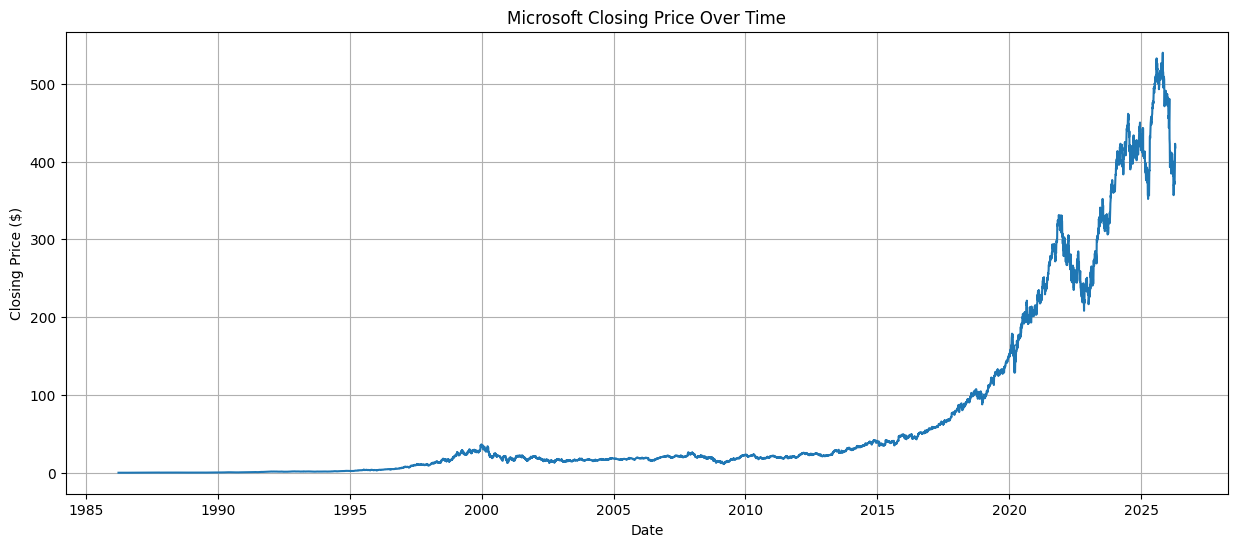

In [ ]:
# Microsoft Kapanış Fiyatlarını Görselleştir


plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Close"])

plt.title("Microsoft Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")

plt.grid(True)

plt.show()

### Target Variable Selection

The **Close** price is selected as the target variable for this study.

Since the objective of this project is to predict the next day's closing stock price, only the **Close** column is extracted from the dataset and used throughout the modeling process.

In [ ]:
# Sadece Close sütununu seç


close_prices = df[["Close"]]

display(close_prices.head())

print("Veri Boyutu:", close_prices.shape)

,Close
0,0.057666
1,0.058724
2,0.058195
3,0.057666
4,0.058195


Veri Boyutu: (10094, 1)


### Statistical Summary

Before normalization, descriptive statistics of the closing prices are examined.

This summary provides information about the distribution of the data, including the minimum, maximum, mean, median, and quartile values.

In [ ]:
close_prices.describe()

,Close
count,10094.000000
mean,68.826037
std,117.972298
min,0.057137
25%,3.884150
50%,19.527411
75%,46.982285
max,539.825195


In [ ]:
print(df["Close"].min())
print(df["Close"].max())

0.057137344032526
539.8251953125


## Dataset Filtering

The original dataset covers a long historical period. To better represent recent market conditions, only stock price data from **2010 onwards** is selected.

This filtering step creates a more relevant dataset for model training and evaluation while reducing the influence of outdated market behavior.

In [ ]:
# Daha güncel ve dengeli bir dönem seçme

df_model = df[df["Date"] >= "2010-01-01"].copy()
df_model = df_model.reset_index(drop=True)

print("Seçilen tarih aralığı:")
print(df_model["Date"].min(), "-", df_model["Date"].max())

print("\nVeri boyutu:")
print(df_model.shape)

print("\nClose fiyat aralığı:")
print("Min:", df_model["Close"].min())
print("Max:", df_model["Close"].max())

Seçilen tarih aralığı:
2010-01-04 00:00:00 - 2026-04-20 00:00:00

Veri boyutu:
(4098, 6)

Close fiyat aralığı:
Min: 17.3150577545166
Max: 539.8251953125


## Train-Test Split

The filtered dataset is divided into training and testing subsets before data preprocessing.

An **80%-20%** split is applied, where the first 80% of the observations are used for training and the remaining 20% are reserved for testing.

Since this is a time series forecasting problem, the chronological order of the data is preserved. The date ranges of both subsets are also displayed to verify that the training set contains earlier observations and the test set contains unseen future observations.

In [46]:
# 2010 sonrası veriyi eğitim ve test olarak ayırma


close_values = df_model[["Close"]].values

raw_train_size = int(len(close_values) * 0.80)

train_raw = close_values[:raw_train_size]
test_raw = close_values[raw_train_size:]

print("Toplam veri:", close_values.shape)
print("Ham eğitim verisi:", train_raw.shape)
print("Ham test verisi:", test_raw.shape)

print("\nEğitim dönemi:")
print(
    df_model["Date"].iloc[0],
    "-",
    df_model["Date"].iloc[raw_train_size - 1]
)

print("\nTest dönemi:")
print(
    df_model["Date"].iloc[raw_train_size],
    "-",
    df_model["Date"].iloc[-1]
)

Toplam veri: (4098, 1)
Ham eğitim verisi: (3278, 1)
Ham test verisi: (820, 1)

Eğitim dönemi:
2010-01-04 00:00:00 - 2023-01-10 00:00:00

Test dönemi:
2023-01-11 00:00:00 - 2026-04-20 00:00:00


## Data Scaling

After splitting the dataset, the training data is normalized using the **MinMaxScaler**.

The scaler is fitted **only on the training data** and then applied to both the training and testing datasets. This approach prevents **data leakage** and ensures that the model is evaluated fairly on unseen data.

Finally, the scaling ranges are checked to verify that the transformation has been applied correctly.

In [ ]:
# Veriyi 0-1 aralığına ölçekleme


scaler = MinMaxScaler(feature_range=(0, 1))

# Scaler yalnızca eğitim verisini öğrenir
scaler.fit(train_raw)

# Eğitim ve test verilerini aynı scaler ile dönüştürür
train_scaled = scaler.transform(train_raw)
test_scaled = scaler.transform(test_raw)

print("Eğitim ölçek aralığı:")
print("Min:", train_scaled.min())
print("Max:", train_scaled.max())

print("\nTest ölçek aralığı:")
print("Min:", test_scaled.min())
print("Max:", test_scaled.max())

Eğitim ölçek aralığı:
Min: 0.0
Max: 0.9999999999999999

Test ölçek aralığı:
Min: 0.66477404579469
Max: 1.6644888940248466


## Creating Time Series Sequences

The normalized training and testing data are converted into input-output sequences using the **sliding window** technique.

A window size of **20** is selected, meaning that the models use the closing prices from the previous 20 trading days to predict the next day's closing price.

To ensure that the first observation in the test set has sufficient historical context, the last 20 days of the training data are appended to the beginning of the test data before creating the test sequences.

In [59]:
# Sliding Window ile Diziler Oluşturma


def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

In [ ]:
# 20 günlük Sliding Window oluşturma


WINDOW_SIZE = 20

X_train, y_train = create_sequences(
    train_scaled,
    WINDOW_SIZE
)

# Testin ilk gününü tahmin edebilmek için
# eğitim döneminin son 20 gününü test verisine ekliyoruz
test_with_context = np.concatenate(
    [train_scaled[-WINDOW_SIZE:], test_scaled],
    axis=0
)

X_test, y_test = create_sequences(
    test_with_context,
    WINDOW_SIZE
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3258, 20, 1)
y_train shape: (3258, 1)
X_test shape: (820, 20, 1)
y_test shape: (820, 1)


## Converting Data to PyTorch Tensors

After creating the input-output sequences, the NumPy arrays are converted into **PyTorch tensors**.

This step is required because PyTorch models can only process tensor objects during training and inference. The converted tensors will be used as inputs for both the LSTM and GRU models.

In [ ]:
# NumPy Dizilerini PyTorch Tensor'a Çevir


X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nVeri tipi:", type(X_train))

X_train: torch.Size([3258, 20, 1])
y_train: torch.Size([3258, 1])
X_test : torch.Size([820, 20, 1])
y_test : torch.Size([820, 1])

Veri tipi: <class 'torch.Tensor'>


## LSTM Model Architecture

The first forecasting model used in this project is the **Long Short-Term Memory (LSTM)** network.

The model consists of:

- Two LSTM layers with **32 hidden units**
- A fully connected (**Linear**) output layer
- A single output representing the predicted closing price

The final hidden representation from the last time step is passed to the output layer to generate the prediction.

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        last_output = lstm_out[:, -1, :]

        prediction = self.fc(last_output)

        return prediction

In [ ]:
lstm_model = LSTMModel()

print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
# İlk eğitim örneğini modele gönderelim

sample_output = lstm_model(X_train[:1])

print("Çıktı boyutu:", sample_output.shape)
print(sample_output)

Çıktı boyutu: torch.Size([1, 1])
tensor([[0.0360]], grad_fn=<AddmmBackward0>)


### Loss Function and Optimizer

To train the LSTM model, the **Mean Squared Error (MSE)** loss function and the **Adam optimizer** are used.

The MSE loss measures the difference between the predicted and actual closing prices, while the Adam optimizer updates the model parameters to minimize this error during training.

In [ ]:
criterion = nn.MSELoss()

print(criterion)

MSELoss()


In [ ]:
optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
EPOCHS = 50

### Model Training

The LSTM model is trained for **50 epochs** using the training dataset.

During each epoch, the model performs a forward pass to generate predictions, computes the loss using the Mean Squared Error (MSE) function, performs backpropagation, and updates its parameters using the Adam optimizer.

The training loss is recorded after each epoch to monitor the learning progress.

In [ ]:
# LSTM Modelini Eğitme


lstm_losses = []

for epoch in range(EPOCHS):

    # Önce eski gradyanları temizle
    optimizer.zero_grad()

    # Eğitim verisini modele ver ve tahmin al
    predictions = lstm_model(X_train)

    # Tahminlerle gerçek değerlerin hatasını hesapla
    loss = criterion(predictions, y_train)

    # Hatanın model ağırlıklarına etkisini hesapla
    loss.backward()

    # Model ağırlıklarını güncelle
    optimizer.step()

    # Her epoch'un loss değerini kaydet
    lstm_losses.append(loss.item())

    # Her 10 epoch'ta sonucu göster
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{EPOCHS}], "
            f"Loss: {loss.item():.8f}"
        )

Epoch [10/50], Loss: 0.07897488
Epoch [20/50], Loss: 0.06898063
Epoch [30/50], Loss: 0.05617525
Epoch [40/50], Loss: 0.02861601
Epoch [50/50], Loss: 0.00452365


### Model Evaluation

After training, the LSTM model is switched to **evaluation mode** and used to generate predictions on the test dataset.

Gradient calculations are disabled during this step to improve efficiency, as the model is no longer being trained. The generated predictions will be used for performance evaluation and comparison with the actual closing prices.

In [ ]:
# LSTM ile Test Tahmini


lstm_model.eval()

with torch.no_grad():
    lstm_test_predictions = lstm_model(X_test)

print("Tahmin boyutu:", lstm_test_predictions.shape)

Tahmin boyutu: torch.Size([820, 1])


### Inverse Data Transformation

The predictions generated by the LSTM model and the corresponding test values are transformed back to their original price scale using the fitted **MinMaxScaler**.

This inverse transformation makes the predicted values directly comparable to the actual Microsoft closing prices and allows the model's performance to be interpreted in real-world units.

In [ ]:
# Tahminleri Gerçek Fiyat Ölçeğine Döndürme

lstm_predictions_real = scaler.inverse_transform(
    lstm_test_predictions.numpy()
)

y_test_real = scaler.inverse_transform(
    y_test.numpy()
)

print("İlk 5 tahmin:")
print(lstm_predictions_real[:5])

print("\nİlk 5 gerçek değer:")
print(y_test_real[:5])

İlk 5 tahmin:
[[206.64644]
 [204.89839]
 [203.65715]
 [202.93034]
 [202.79422]]

İlk 5 gerçek değer:
[[229.74022]
 [232.41016]
 [233.11177]
 [234.20312]
 [229.77922]]


### Performance Evaluation

The performance of the LSTM model is evaluated using the **Root Mean Squared Error (RMSE)** metric.

RMSE measures the average prediction error in the original price scale. A lower RMSE value indicates that the predicted closing prices are closer to the actual closing prices, reflecting better model performance.

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test_real,
        lstm_predictions_real
    )
)

print("LSTM RMSE:", rmse)

LSTM RMSE: 31.976713290629068


### Prediction Visualization

The predicted closing prices generated by the LSTM model are plotted together with the actual closing prices.

This visualization provides a qualitative assessment of the model's performance by showing how closely the predicted values follow the overall trend of the real stock prices.

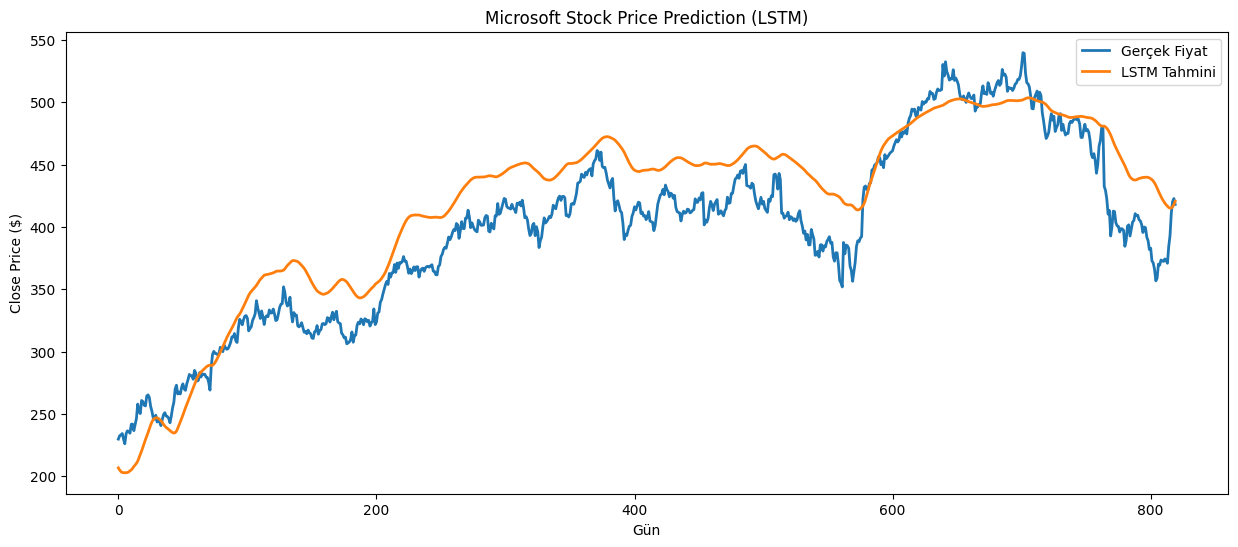

In [ ]:
# LSTM Tahmin Grafiği

import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    y_test_real,
    label="Gerçek Fiyat",
    linewidth=2
)

plt.plot(
    lstm_predictions_real,
    label="LSTM Tahmini",
    linewidth=2
)

plt.title("Microsoft Stock Price Prediction (LSTM)")
plt.xlabel("Gün")
plt.ylabel("Close Price ($)")
plt.legend()

plt.show()

## GRU Model Architecture

The second forecasting model used in this project is the **Gated Recurrent Unit (GRU)** network.

To ensure a fair comparison with the LSTM model, the GRU model uses the same main hyperparameters:

- An input size of **1**, representing the closing price
- Two GRU layers with **32 hidden units**
- A fully connected (**Linear**) output layer
- A single output representing the predicted next-day closing price

The final hidden representation from the last time step is passed to the output layer to generate the prediction.

In [48]:
# GRU Model Architecture


class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        gru_out, _ = self.gru(x)

        last_output = gru_out[:, -1, :]

        prediction = self.fc(last_output)

        return prediction

In [49]:
gru_model = GRUModel()

print(gru_model)

GRUModel(
  (gru): GRU(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


### Loss Function and Optimizer

To train the GRU model, the **Mean Squared Error (MSE)** loss function and the **Adam optimizer** are used.

The MSE loss measures the difference between the predicted and actual closing prices, while the Adam optimizer updates the GRU model parameters to minimize this error during training.

In [51]:
# GRU Loss Function and Optimizer


gru_criterion = nn.MSELoss()

gru_optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

print(gru_criterion)
print(gru_optimizer)

MSELoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


### Model Training

The GRU model is trained for **50 epochs** using the training dataset.

During each epoch, the model performs a forward pass to generate predictions, computes the loss using the Mean Squared Error (MSE) function, performs backpropagation, and updates its parameters using the Adam optimizer.

The training loss is recorded after each epoch to monitor the learning progress.

In [52]:
# GRU Model Training


gru_losses = []

for epoch in range(EPOCHS):

    # Önce eski gradyanları temizle
    gru_optimizer.zero_grad()

    # Eğitim verisini modele ver ve tahmin al
    predictions = gru_model(X_train)

    # Hata hesapla
    loss = gru_criterion(predictions, y_train)

    # Geri yayılım
    loss.backward()

    # Ağırlıkları güncelle
    gru_optimizer.step()

    # Loss değerini kaydet
    gru_losses.append(loss.item())

    # Her 10 epoch'ta loss'u yazdır
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{EPOCHS}], "
            f"Loss: {loss.item():.8f}"
        )

Epoch [10/50], Loss: 0.07197519
Epoch [20/50], Loss: 0.05633227
Epoch [30/50], Loss: 0.03840559
Epoch [40/50], Loss: 0.01674368
Epoch [50/50], Loss: 0.00064294


### Model Evaluation

After training, the GRU model is switched to evaluation mode and used to generate predictions on the test dataset.

Gradient calculations are disabled during this step because the model is no longer being trained. The generated predictions will later be transformed back to the original price scale and compared with the actual closing prices.

In [53]:
# GRU Model Evaluation

gru_model.eval()

with torch.no_grad():
    gru_test_predictions = gru_model(X_test)

print("Tahmin boyutu:", gru_test_predictions.shape)

Tahmin boyutu: torch.Size([820, 1])


### Inverse Data Transformation

The predictions generated by the GRU model are transformed back to the original price scale using the fitted **MinMaxScaler**.

This step makes the predicted values directly comparable with the actual Microsoft closing prices and allows the model performance to be interpreted in real-world units.

In [54]:
# GRU Predictions in Original Price Scale


gru_predictions_real = scaler.inverse_transform(
    gru_test_predictions.numpy()
)

print("İlk 5 GRU tahmini:")
print(gru_predictions_real[:5])

print("\nİlk 5 gerçek değer:")
print(y_test_real[:5])

İlk 5 GRU tahmini:
[[244.42319]
 [244.33588]
 [245.05951]
 [246.15215]
 [247.4297 ]]

İlk 5 gerçek değer:
[[229.74022]
 [232.41016]
 [233.11177]
 [234.20312]
 [229.77922]]


### Performance Evaluation

The performance of the GRU model is evaluated using the **Root Mean Squared Error (RMSE)** metric.

RMSE measures the average prediction error in the original price scale. Lower RMSE values indicate that the predicted closing prices are closer to the actual closing prices, representing better forecasting performance.

In [55]:
# GRU Performance Evaluation

from sklearn.metrics import mean_squared_error
import numpy as np

gru_rmse = np.sqrt(
    mean_squared_error(
        y_test_real,
        gru_predictions_real
    )
)

print("GRU RMSE:", gru_rmse)

GRU RMSE: 21.00710866592433


### Prediction Visualization

The predicted closing prices generated by the GRU model are plotted together with the actual closing prices.

This visualization provides a qualitative assessment of the model's performance by showing how closely the predicted values follow the overall trend of the real stock prices.

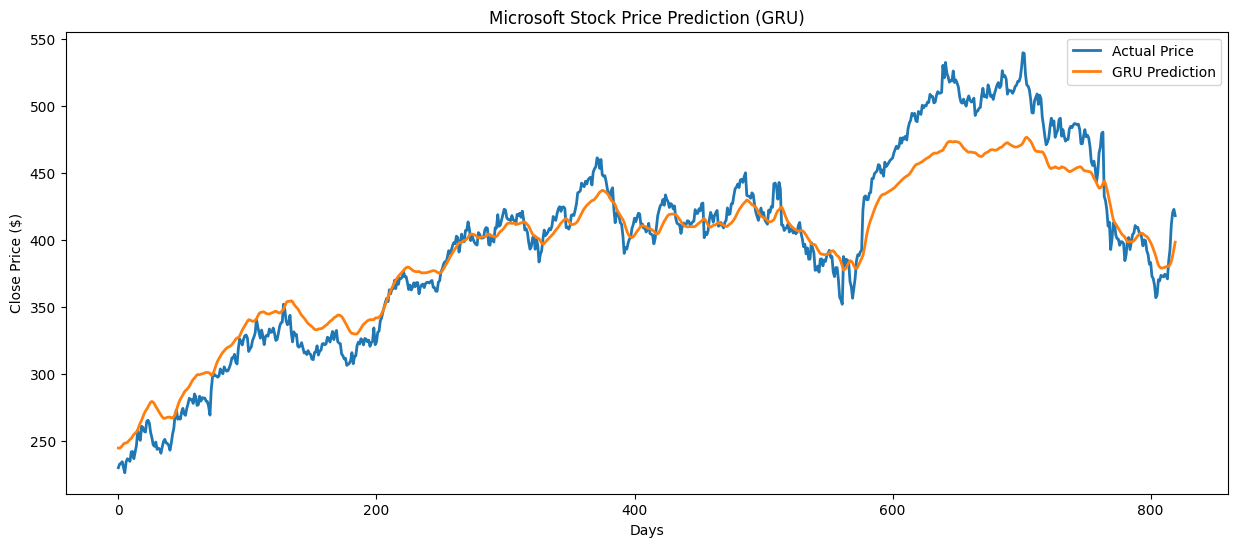

In [56]:
# GRU Prediction Visualization


import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    y_test_real,
    label="Actual Price",
    linewidth=2
)

plt.plot(
    gru_predictions_real,
    label="GRU Prediction",
    linewidth=2
)

plt.title("Microsoft Stock Price Prediction (GRU)")
plt.xlabel("Days")
plt.ylabel("Close Price ($)")
plt.legend()

plt.show()

## Model Comparison

The LSTM and GRU models are compared using their test RMSE values.

A lower RMSE indicates that the model's predictions are closer to the actual Microsoft closing prices. Both models were trained using the same dataset, window size, number of layers, hidden size, optimizer, learning rate, and number of epochs to ensure a fair comparison.

In [57]:
# LSTM and GRU Model Comparison


comparison_df = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "Test RMSE": [rmse, gru_rmse]
})

comparison_df

,Model,Test RMSE
0,LSTM,31.976713
1,GRU,21.007109


### Comparison of Model Predictions

The predictions generated by both the LSTM and GRU models are compared with the actual Microsoft closing prices.

This visualization provides a direct comparison of the two models and illustrates which model follows the overall trend of the stock prices more closely.

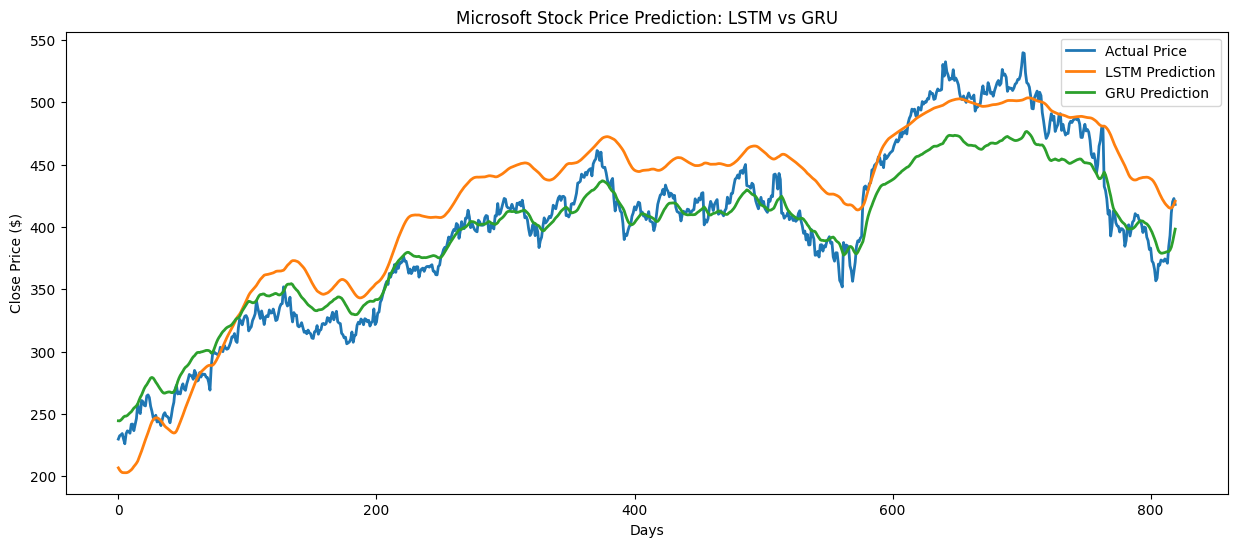

In [58]:
# LSTM vs GRU Prediction Comparison


plt.figure(figsize=(15,6))

# Gerçek fiyatlar
plt.plot(
    y_test_real,
    label="Actual Price",
    linewidth=2
)

# LSTM
plt.plot(
    lstm_predictions_real,
    label="LSTM Prediction",
    linewidth=2
)

# GRU
plt.plot(
    gru_predictions_real,
    label="GRU Prediction",
    linewidth=2
)

plt.title("Microsoft Stock Price Prediction: LSTM vs GRU")
plt.xlabel("Days")
plt.ylabel("Close Price ($)")
plt.legend()

plt.show()

# Conclusion

In this project, two recurrent neural network architectures, **LSTM** and **GRU**, were implemented to predict Microsoft's daily closing stock prices.

Both models were trained using the same dataset, preprocessing pipeline, sliding window size, and hyperparameters to ensure a fair comparison.

The experimental results showed that the **GRU model achieved a lower RMSE (21.01)** than the **LSTM model (31.98)** on the test dataset. This indicates that the GRU model captured the temporal patterns in the stock prices more effectively under the selected experimental settings.

Overall, both models successfully learned the long-term trend of Microsoft's stock prices, while the GRU model produced predictions that were closer to the actual values.

In addition, the GRU model is generally expected to train faster than the LSTM model because it has a simpler architecture with fewer parameters. This makes GRU computationally more efficient while maintaining strong prediction performance.

# Future Work

Several improvements could be explored in future studies:

- Incorporating additional stock market features such as trading volume, opening price, high price, and low price.
- Experimenting with different window sizes and hyperparameters.
- Evaluating more advanced deep learning architectures such as Transformer-based models.
- Comparing the models using additional evaluation metrics such as MAE and MAPE.
- Applying the proposed methodology to different companies or financial markets.